# Feature EDA — NVIDIA Developer Journey
Primary table: `dev_profile_final_v4` (9.38M developers, from FeatureEngineering_v2)

**Key context:** 78% of developers are Unactivated (never crossed the activation gate). Most features are zero or null for this group. Sections that analyze behavioral features filter to the activated population unless stated otherwise.

**v4 changes vs v3:** Non-overlapping windows (0–30d, 30–90d, 90–180d), new `behavior_journey_stage_30d`, composite `developer_effort_score`, `final_lifecycle_status`, normalized persona shares + entropy.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

T = 'dev_profile_final_v4'
con = duckdb.connect('developer_project.duckdb', read_only=True)

schema = con.execute(f'DESCRIBE {T}').fetchdf()
all_cols = schema['column_name'].tolist()
total = con.execute(f'SELECT COUNT(*) FROM {T}').fetchone()[0]
print(f'{T}: {len(all_cols)} columns, {total:,} developers')
display(schema[['column_name', 'column_type']])

dev_profile_final_v4: 145 columns, 9,381,508 developers


,column_name,column_type
0,developer_id,VARCHAR
1,persona,VARCHAR
2,persona_confidence,DOUBLE
3,persona_confidence_tier,VARCHAR
4,persona_entropy,DOUBLE
...,...,...
140,organization_english_name,VARCHAR
141,normalized_account_name,VARCHAR
142,wwfo_category,VARCHAR
143,wwfo_target_list,VARCHAR


## 1. Population Overview — The Big Picture
Understanding the activation/dormancy split is essential context for every other section.

Total:        9,381,508
Activated:    7,660,278  (81.7%)
Unactivated:  1,721,230  (18.3%)


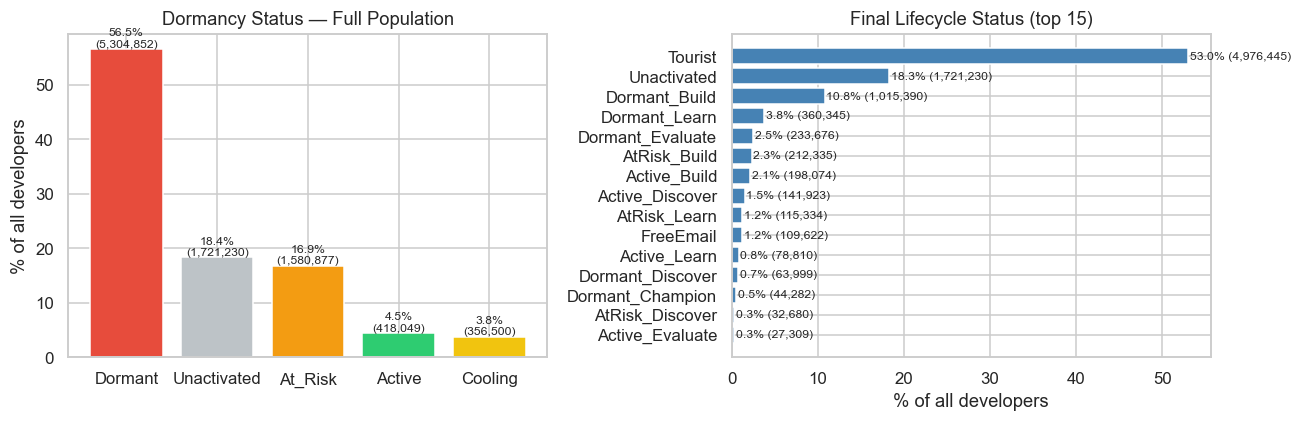

In [2]:
dormancy = con.execute(f"""
    SELECT dormancy_status,
           COUNT(*) AS developers,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM {T} GROUP BY 1 ORDER BY 2 DESC
""").fetchdf()

n_activated = int(con.execute(f'SELECT SUM(is_activated) FROM {T}').fetchone()[0])
n_unactivated = total - n_activated
print(f'Total:       {total:>10,}')
print(f'Activated:   {n_activated:>10,}  ({n_activated/total*100:.1f}%)')
print(f'Unactivated: {n_unactivated:>10,}  ({n_unactivated/total*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Dormancy status
colors = {'Active': '#2ecc71', 'At_Risk': '#f39c12', 'Cooling': '#f1c40f',
          'Dormant': '#e74c3c', 'Unactivated': '#bdc3c7'}
bar_colors = [colors.get(s, 'steelblue') for s in dormancy['dormancy_status']]
bars = axes[0].bar(dormancy['dormancy_status'], dormancy['pct'], color=bar_colors)
axes[0].set_ylabel('% of all developers')
axes[0].set_title('Dormancy Status — Full Population')
for bar, (_, row) in zip(bars, dormancy.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{row['pct']:.1f}%\n({row['developers']:,})", ha='center', fontsize=8)

# activation_reason if present, else top final_lifecycle_status categories
if 'activation_reason' in all_cols:
    act_reason = con.execute(f"""
        SELECT activation_reason AS label, COUNT(*) AS developers,
               ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 1) AS pct
        FROM {T} GROUP BY 1 ORDER BY 2 DESC
    """).fetchdf()
    title = 'Activation Reason Breakdown'
elif 'final_lifecycle_status' in all_cols:
    act_reason = con.execute(f"""
        SELECT final_lifecycle_status AS label, COUNT(*) AS developers,
               ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 1) AS pct
        FROM {T} GROUP BY 1 ORDER BY 2 DESC LIMIT 15
    """).fetchdf()
    title = 'Final Lifecycle Status (top 15)'
else:
    act_reason = None

if act_reason is not None:
    axes[1].barh(act_reason['label'][::-1], act_reason['pct'][::-1], color='steelblue')
    axes[1].set_xlabel('% of all developers')
    axes[1].set_title(title)
    for i, (_, row) in enumerate(act_reason[::-1].iterrows()):
        axes[1].text(row['pct'] + 0.2, i, f"{row['pct']:.1f}% ({row['developers']:,})",
                     va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 2. Missingness — What's Missing and Why

In [3]:
null_exprs = ', '.join(f'SUM(CASE WHEN {c} IS NULL THEN 1 ELSE 0 END) AS "{c}"' for c in all_cols)
null_counts = con.execute(f'SELECT {null_exprs} FROM {T}').fetchdf()

missingness = pd.DataFrame({
    'column': all_cols,
    'null_count': null_counts.values[0].astype(int),
    'null_pct': null_counts.values[0] / total * 100
}).sort_values('null_pct', ascending=False)

# Annotate known explanations
notes = {
    'days_since_last_activity': 'NULL = no activity in 30d window (all Unactivated + most Dormant)',
    'days_since_last_meaningful_week': 'NULL = Unactivated developers (78.1% of population)',
    'last_meaningful_week_start': 'NULL = Unactivated (no meaningful week ever recorded)',
    'lifetime_first_activity_date': 'NULL = developer has zero lifetime activity',
    'lifetime_last_activity_date': 'NULL = developer has zero lifetime activity',
}
missingness['note'] = missingness['column'].map(notes).fillna('')
display(missingness[missingness['null_pct'] > 0][['column', 'null_count', 'null_pct', 'note']].reset_index(drop=True))

,column,null_count,null_pct,note
0,build_velocity_0_30_vs_30_90,9290121,99.03,
1,build_share_0_30d,8963459,95.54,
2,high_effort_share_0_30d,8963459,95.54,
3,confidence_weighted_effort_per_activity_0_30d,8963459,95.54,
4,days_since_last_activity_0_30d,8963459,95.54,
5,activity_per_active_day_0_30d,8963459,95.54,
6,score_effort_misalignment_share_0_30d,8963459,95.54,
7,activity_velocity_0_30_vs_30_90,8956236,95.47,
8,days_since_last_meaningful_week,5284222,56.33,NULL = Unactivated developers (78.1% of popula...
9,last_meaningful_week_start,5284222,56.33,NULL = Unactivated (no meaningful week ever re...


## 3. Persona Distribution

,persona,developers,pct_all,avg_confidence_pct
0,CUDA,3519981,37.52,71.80
1,GenAI,2314671,24.67,77.00
2,Unknown,1869569,19.93,0.00
3,Robotics,590804,6.30,77.90
4,Simulation,570051,6.08,95.80
5,Learning_Community,516432,5.50,77.80


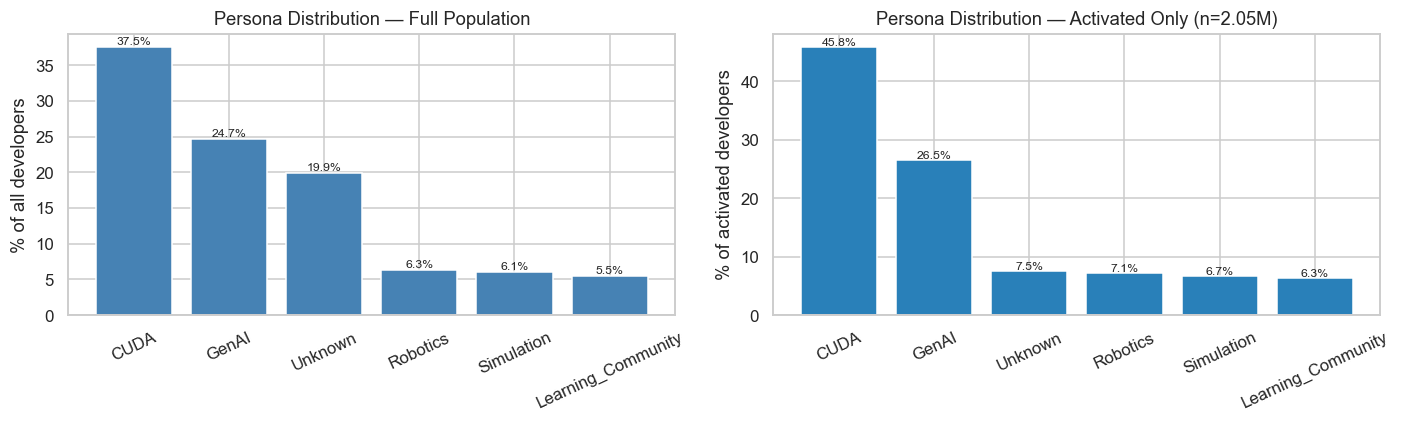

In [4]:
# Full population persona split
persona_dist = con.execute(f"""
    SELECT persona,
           COUNT(*) AS developers,
           ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 2) AS pct_all,
           ROUND(AVG(persona_confidence)*100, 1) AS avg_confidence_pct
    FROM {T} GROUP BY 1 ORDER BY 2 DESC
""").fetchdf()
display(persona_dist)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(persona_dist['persona'], persona_dist['pct_all'], color='steelblue')
axes[0].set_ylabel('% of all developers')
axes[0].set_title('Persona Distribution — Full Population')
axes[0].tick_params(axis='x', rotation=25)
for i, row in persona_dist.iterrows():
    axes[0].text(i, row['pct_all'] + 0.3, f"{row['pct_all']:.1f}%", ha='center', fontsize=8)

# Activated-only persona split
persona_act = con.execute(f"""
    SELECT persona, COUNT(*) AS developers,
           ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 2) AS pct
    FROM {T} WHERE is_activated = 1 GROUP BY 1 ORDER BY 2 DESC
""").fetchdf()
axes[1].bar(persona_act['persona'], persona_act['pct'], color='#2980b9')
axes[1].set_ylabel('% of activated developers')
axes[1].set_title('Persona Distribution — Activated Only (n=2.05M)')
axes[1].tick_params(axis='x', rotation=25)
for i, row in persona_act.iterrows():
    axes[1].text(i, row['pct'] + 0.3, f"{row['pct']:.1f}%", ha='center', fontsize=8)

plt.tight_layout()
plt.show()

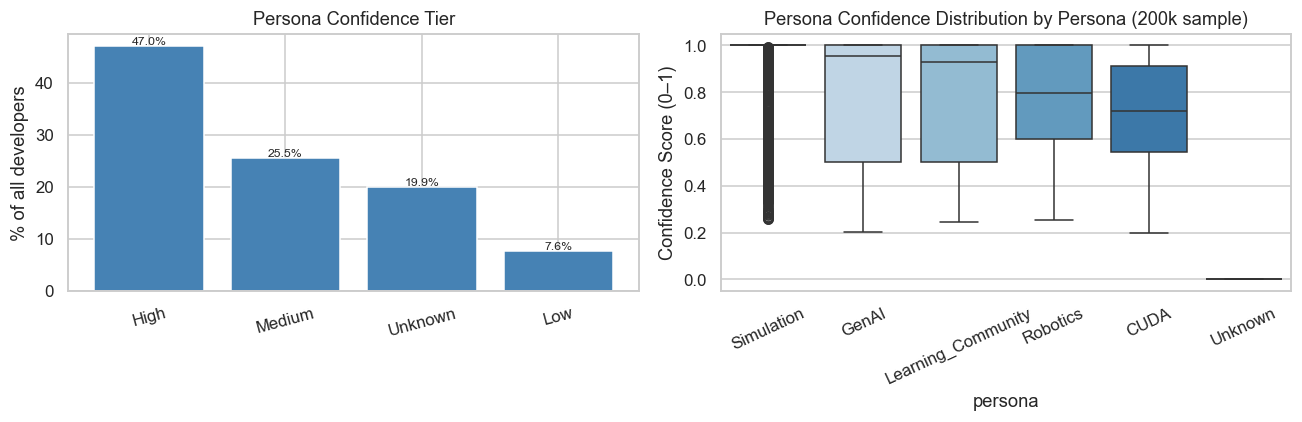

Mixed persona flag=1: 2,297,790 (24.5%) developers scored in multiple personas


In [5]:
# Persona confidence tier and mixed persona
conf_tier = con.execute(f"""
    SELECT persona_confidence_tier,
           COUNT(*) AS developers,
           ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 1) AS pct
    FROM {T} GROUP BY 1 ORDER BY 2 DESC
""").fetchdf()

mixed = con.execute(f"""
    SELECT mixed_persona_flag, COUNT(*) AS developers,
           ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 1) AS pct
    FROM {T} GROUP BY 1
""").fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(conf_tier['persona_confidence_tier'].astype(str), conf_tier['pct'], color='steelblue')
axes[0].set_title('Persona Confidence Tier')
axes[0].set_ylabel('% of all developers')
axes[0].tick_params(axis='x', rotation=15)
for i, row in conf_tier.iterrows():
    axes[0].text(i, row['pct'] + 0.3, f"{row['pct']:.1f}%", ha='center', fontsize=8)

# Confidence distribution per persona (boxplot on 100k sample)
sample_conf = con.execute(f"""
    SELECT persona, persona_confidence
    FROM {T}
    USING SAMPLE 200000 ROWS
""").fetchdf()
persona_order = sample_conf.groupby('persona')['persona_confidence'].median().sort_values(ascending=False).index
sns.boxplot(data=sample_conf, x='persona', y='persona_confidence',
            order=persona_order, ax=axes[1], palette='Blues')
axes[1].set_title('Persona Confidence Distribution by Persona (200k sample)')
axes[1].set_ylabel('Confidence Score (0–1)')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

print(f"Mixed persona flag=1: {mixed[mixed['mixed_persona_flag']==1]['developers'].values[0]:,} ({mixed[mixed['mixed_persona_flag']==1]['pct'].values[0]:.1f}%) developers scored in multiple personas")

## 3b. Unknown Persona Deep-Dive
22.3% of developers are classified as Unknown — no dominant signal from their activity history. This section compares Unknown developers against named personas to understand whether Unknown is a distinct behavioral segment or simply a data sparsity artifact.

,persona_group,persona,total,activation_rate_pct,avg_confidence,avg_lifetime_activity
0,Named Persona,CUDA,3519981,99.70,0.72,8.70
1,Named Persona,GenAI,2314671,87.70,0.77,5.90
2,Named Persona,Robotics,590804,92.60,0.78,34.00
3,Named Persona,Simulation,570051,89.80,0.96,3.40
4,Named Persona,Learning_Community,516432,93.70,0.78,3.30
5,Unknown,Unknown,1869569,30.80,0.00,0.70


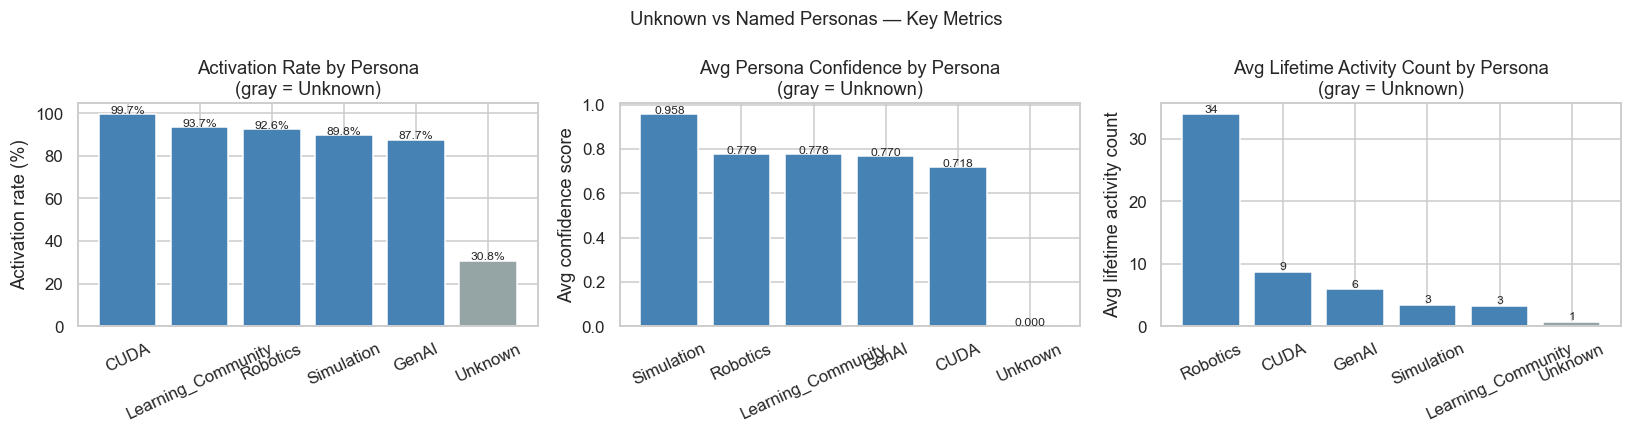

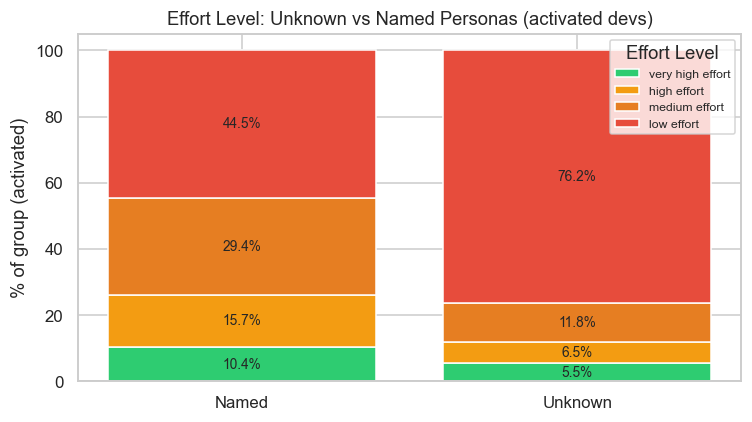

In [6]:
# Unknown persona vs named personas — activation rate, effort level, journey stage
unknown_compare = con.execute(f"""
    SELECT
        CASE WHEN persona = 'Unknown' THEN 'Unknown' ELSE 'Named Persona' END AS persona_group,
        persona,
        COUNT(*) AS total,
        ROUND(AVG(is_activated) * 100, 1) AS activation_rate_pct,
        ROUND(AVG(persona_confidence), 3) AS avg_confidence,
        ROUND(AVG(lifetime_activity_count), 1) AS avg_lifetime_activity
    FROM {T}
    GROUP BY 1, 2 ORDER BY 1, 3 DESC
""").fetchdf()
display(unknown_compare)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Activation rate: Unknown vs each named persona
act_df = unknown_compare.sort_values('activation_rate_pct', ascending=False)
colors_act = ['#95a5a6' if p == 'Unknown' else 'steelblue' for p in act_df['persona']]
axes[0].bar(act_df['persona'], act_df['activation_rate_pct'], color=colors_act)
axes[0].set_title('Activation Rate by Persona\n(gray = Unknown)')
axes[0].set_ylabel('Activation rate (%)')
axes[0].tick_params(axis='x', rotation=25)
for i, (_, row) in enumerate(act_df.iterrows()):
    axes[0].text(i, row['activation_rate_pct'] + 0.3, f"{row['activation_rate_pct']:.1f}%", ha='center', fontsize=8)

# 2. Avg persona confidence
conf_df = unknown_compare.sort_values('avg_confidence', ascending=False)
colors_conf = ['#95a5a6' if p == 'Unknown' else 'steelblue' for p in conf_df['persona']]
axes[1].bar(conf_df['persona'], conf_df['avg_confidence'], color=colors_conf)
axes[1].set_title('Avg Persona Confidence by Persona\n(gray = Unknown)')
axes[1].set_ylabel('Avg confidence score')
axes[1].tick_params(axis='x', rotation=25)
for i, (_, row) in enumerate(conf_df.iterrows()):
    axes[1].text(i, row['avg_confidence'] + 0.002, f"{row['avg_confidence']:.3f}", ha='center', fontsize=8)

# 3. Avg lifetime activity
act_vol = unknown_compare.sort_values('avg_lifetime_activity', ascending=False)
colors_vol = ['#95a5a6' if p == 'Unknown' else 'steelblue' for p in act_vol['persona']]
axes[2].bar(act_vol['persona'], act_vol['avg_lifetime_activity'], color=colors_vol)
axes[2].set_title('Avg Lifetime Activity Count by Persona\n(gray = Unknown)')
axes[2].set_ylabel('Avg lifetime activity count')
axes[2].tick_params(axis='x', rotation=25)
for i, (_, row) in enumerate(act_vol.iterrows()):
    axes[2].text(i, row['avg_lifetime_activity'] + 0.3, f"{row['avg_lifetime_activity']:.0f}", ha='center', fontsize=8)

plt.suptitle('Unknown vs Named Personas — Key Metrics', fontsize=12)
plt.tight_layout()
plt.show()

# Effort level breakdown: Unknown vs named (activated only)
if 'developer_effort_level' in all_cols:
    effort_unk = con.execute(f"""
        SELECT
            CASE WHEN persona = 'Unknown' THEN 'Unknown' ELSE 'Named' END AS persona_group,
            developer_effort_level,
            COUNT(*) AS developers,
            ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER (PARTITION BY CASE WHEN persona='Unknown' THEN 'Unknown' ELSE 'Named' END), 1) AS pct
        FROM {T}
        WHERE is_activated = 1 AND developer_effort_level IS NOT NULL
        GROUP BY 1, 2
    """).fetchdf()

    pivot_eff = effort_unk.pivot(index='persona_group', columns='developer_effort_level', values='pct').fillna(0)
    e_order = [c for c in ['very high effort','high effort','medium effort','low effort'] if c in pivot_eff.columns]
    pivot_eff = pivot_eff[e_order]

    fig, ax = plt.subplots(figsize=(7, 4))
    bottom = np.zeros(len(pivot_eff))
    e_colors = {'very high effort':'#2ecc71','high effort':'#f39c12','medium effort':'#e67e22','low effort':'#e74c3c'}
    for level in e_order:
        vals = pivot_eff[level].values
        ax.bar(pivot_eff.index, vals, bottom=bottom, label=level, color=e_colors.get(level,'gray'))
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 3:
                ax.text(i, b + v/2, f'{v:.1f}%', ha='center', va='center', fontsize=9)
        bottom += vals
    ax.set_ylabel('% of group (activated)')
    ax.set_title('Effort Level: Unknown vs Named Personas (activated devs)')
    ax.legend(title='Effort Level', fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.show()

## 4. Activity Counts — Zero vs Non-Zero
Most developers have zero recent activity. We show the zero/non-zero split first, then the distribution within the non-zero group.

Activity count columns found: ['activity_count_0_30d', 'activity_count_30_90d', 'activity_count_90_180d', 'lifetime_activity_count']


,window,pct_any_activity,n_nonzero
0,0 30d,4.50,418049
1,30 90d,4.50,425272
2,90 180d,5.60,520752
3,lifetime activity count,81.70,7660278


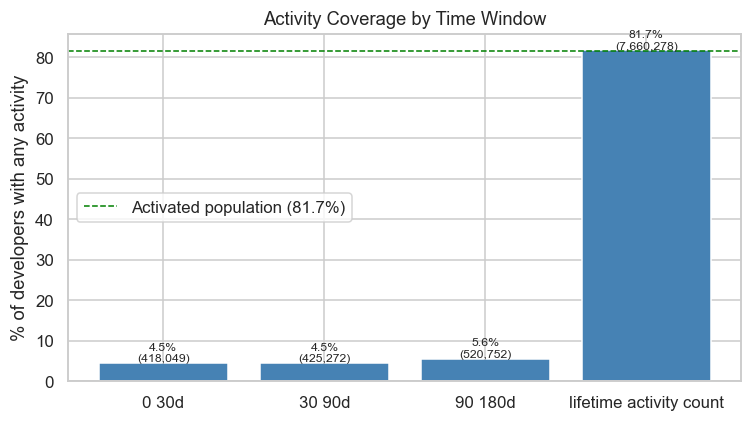

In [7]:
# v4 uses non-overlapping windows: 0_30d, 30_90d, 90_180d
count_cols = [c for c in [
    'activity_count_0_30d', 'activity_count_30_90d', 'activity_count_90_180d', 'lifetime_activity_count'
] if c in all_cols]

print('Activity count columns found:', count_cols)

# % with any activity per window
any_activity = []
for col in count_cols:
    n_nonzero = con.execute(f'SELECT COUNT(*) FROM {T} WHERE {col} > 0').fetchone()[0]
    any_activity.append({'window': col.replace('activity_count_', '').replace('_', ' '),
                         'pct_any_activity': round(n_nonzero / total * 100, 1),
                         'n_nonzero': n_nonzero})
any_df = pd.DataFrame(any_activity)
display(any_df)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(any_df['window'], any_df['pct_any_activity'], color='steelblue')
ax.set_ylabel('% of developers with any activity')
ax.set_title('Activity Coverage by Time Window')
ax.axhline(n_activated/total*100, color='green', linestyle='--', linewidth=1,
           label=f'Activated population ({n_activated/total*100:.1f}%)')
ax.legend()
for bar, (_, row) in zip(bars, any_df.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{row['pct_any_activity']:.1f}%\n({row['n_nonzero']:,})", ha='center', fontsize=8)
plt.tight_layout()
plt.show()

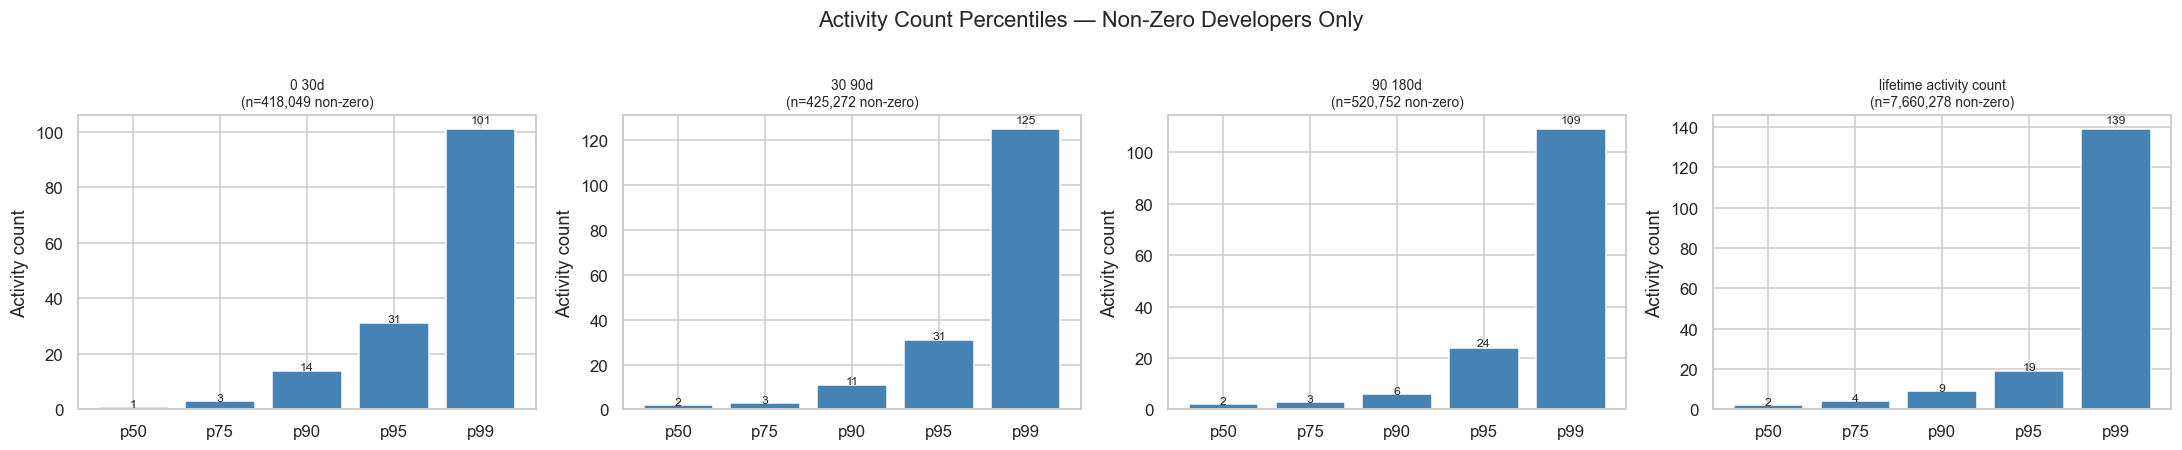

In [8]:
# Distribution of activity counts — NON-ZERO developers only
fig, axes = plt.subplots(1, len(count_cols), figsize=(5 * len(count_cols), 4), sharey=False)

for ax, col in zip(axes, count_cols):
    label = col.replace('activity_count_', '').replace('_', ' ')
    p50, p75, p90, p95, p99 = con.execute(f"""
        SELECT
            APPROX_QUANTILE({col}, 0.50),
            APPROX_QUANTILE({col}, 0.75),
            APPROX_QUANTILE({col}, 0.90),
            APPROX_QUANTILE({col}, 0.95),
            APPROX_QUANTILE({col}, 0.99)
        FROM {T} WHERE {col} > 0
    """).fetchone()
    pcts = [p50, p75, p90, p95, p99]
    labels = ['p50', 'p75', 'p90', 'p95', 'p99']
    ax.bar(labels, pcts, color='steelblue')
    n = con.execute(f'SELECT COUNT(*) FROM {T} WHERE {col} > 0').fetchone()[0]
    ax.set_title(f'{label}\n(n={n:,} non-zero)', fontsize=9)
    ax.set_ylabel('Activity count')
    for i, v in enumerate(pcts):
        ax.text(i, v * 1.02, f'{v:,.0f}', ha='center', fontsize=8)

plt.suptitle('Activity Count Percentiles — Non-Zero Developers Only', y=1.02)
plt.tight_layout()
plt.show()

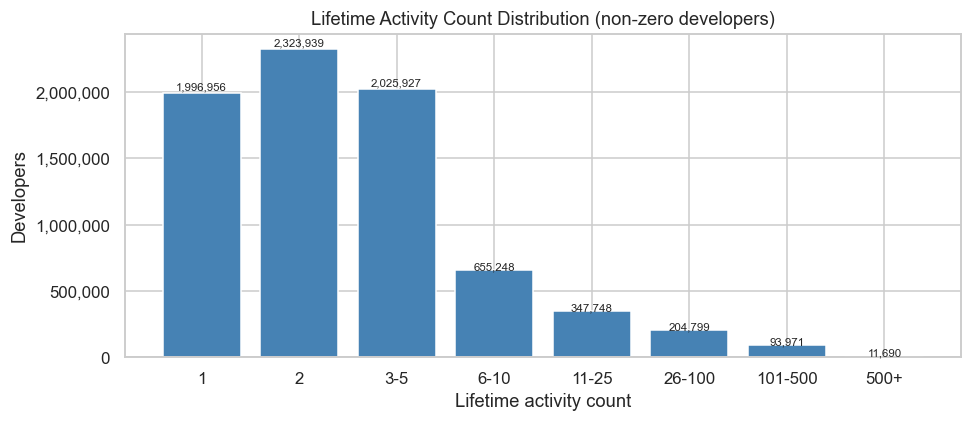

In [9]:
# Log-scale histogram for lifetime activity (most informative window)
bins = con.execute(f"""
    SELECT
        CASE
            WHEN lifetime_activity_count = 1   THEN '1'
            WHEN lifetime_activity_count <= 2  THEN '2'
            WHEN lifetime_activity_count <= 5  THEN '3-5'
            WHEN lifetime_activity_count <= 10 THEN '6-10'
            WHEN lifetime_activity_count <= 25 THEN '11-25'
            WHEN lifetime_activity_count <= 100 THEN '26-100'
            WHEN lifetime_activity_count <= 500 THEN '101-500'
            ELSE '500+'
        END AS bucket,
        MIN(lifetime_activity_count) AS sort_key,
        COUNT(*) AS developers
    FROM {T} WHERE lifetime_activity_count > 0
    GROUP BY 1 ORDER BY sort_key
""").fetchdf()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(bins['bucket'], bins['developers'], color='steelblue')
ax.set_xlabel('Lifetime activity count')
ax.set_ylabel('Developers')
ax.set_title('Lifetime Activity Count Distribution (non-zero developers)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for i, (_, row) in enumerate(bins.iterrows()):
    ax.text(i, row['developers'] * 1.01, f'{row["developers"]:,}', ha='center', fontsize=7.5)
plt.tight_layout()
plt.show()

## 5. Binary Flags Summary

,flag,n_true,pct_true
0,is_activated,7660278,81.65
4,dormant_flag,5304852,56.55
1,mixed_persona_flag,2297790,24.49
5,at_risk_flag,1580877,16.85
2,recent_build_flag,45035,0.48
3,recent_champion_flag,1823,0.02


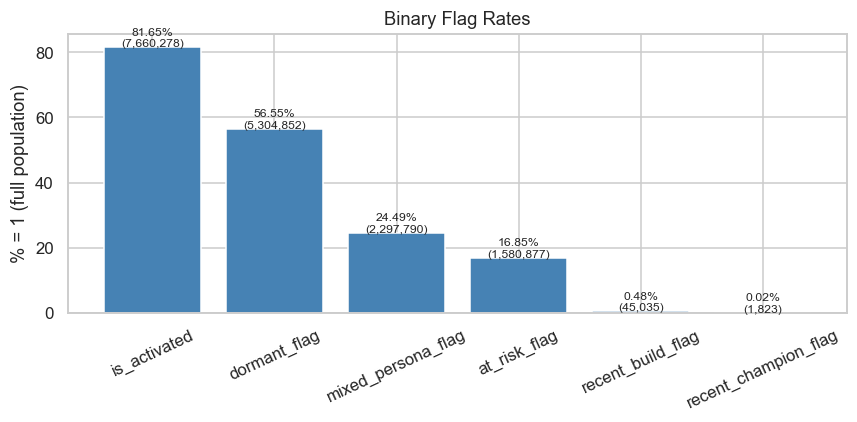

In [10]:
binary_cols = ['is_activated', 'mixed_persona_flag', 'recent_build_flag',
               'recent_champion_flag', 'dormant_flag', 'at_risk_flag']

flag_rows = []
for col in binary_cols:
    n1 = con.execute(f'SELECT SUM({col}) FROM {T}').fetchone()[0] or 0
    pct = n1 / total * 100
    flag_rows.append({'flag': col, 'n_true': int(n1), 'pct_true': round(pct, 2)})
flag_df = pd.DataFrame(flag_rows).sort_values('pct_true', ascending=False)
display(flag_df)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(flag_df['flag'], flag_df['pct_true'], color='steelblue')
ax.set_ylabel('% = 1 (full population)')
ax.set_title('Binary Flag Rates')
ax.tick_params(axis='x', rotation=25)
for bar, (_, row) in zip(bars, flag_df.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{row['pct_true']:.2f}%\n({row['n_true']:,})", ha='center', fontsize=8)
plt.tight_layout()
plt.show()

dormant_flag × dormancy_status cross-tabulation:


,dormancy_status,dormant_flag,developers,pct_all
0,Active,0,418049,4.46
1,At_Risk,0,1580877,16.85
2,Cooling,0,356500,3.80
3,Dormant,1,5304852,56.55
4,Unactivated,0,1721230,18.35



Cross-tab (counts):


,flag=0,flag=1,row_total
dormancy_status,,,
Active,418049,0,418049
At_Risk,1580877,0,1580877
Cooling,356500,0,356500
Dormant,0,5304852,5304852
Unactivated,1721230,0,1721230



✓ dormant_flag and dormancy_status agree perfectly.


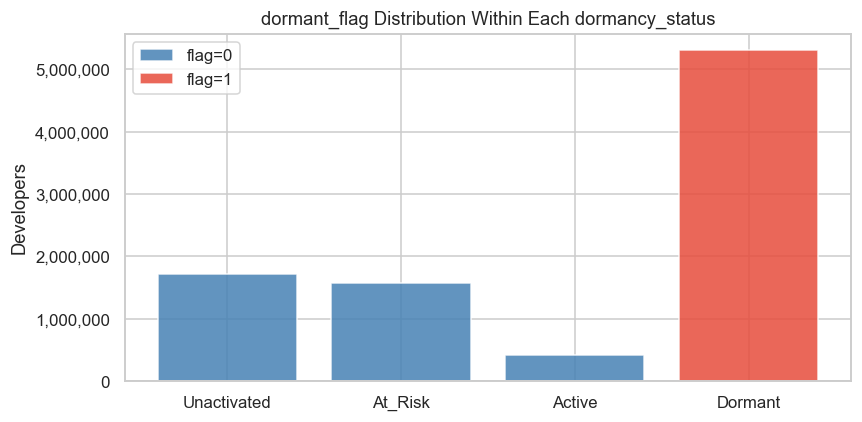

In [11]:
# Cross-check: dormant_flag vs dormancy_status
# dormant_flag=1 should correspond to dormancy_status='Dormant' only.
# Any mismatch (e.g. flag=1 but status='At_Risk') indicates a definition gap in FE.
xtab = con.execute(f"""
    SELECT
        dormancy_status,
        dormant_flag,
        COUNT(*) AS developers,
        ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 2) AS pct_all
    FROM {T}
    GROUP BY 1, 2
    ORDER BY 1, 2
""").fetchdf()

print('dormant_flag × dormancy_status cross-tabulation:')
display(xtab)

pivot_xt = xtab.pivot(index='dormancy_status', columns='dormant_flag', values='developers').fillna(0).astype(int)
pivot_xt.columns = [f'flag={int(c)}' for c in pivot_xt.columns]
pivot_xt['row_total'] = pivot_xt.sum(axis=1)
print('\nCross-tab (counts):')
display(pivot_xt)

# Flag any population where flag and status disagree
mismatches = xtab[
    ((xtab['dormant_flag'] == 1) & (xtab['dormancy_status'] != 'Dormant')) |
    ((xtab['dormant_flag'] == 0) & (xtab['dormancy_status'] == 'Dormant'))
]
if mismatches.empty:
    print('\n✓ dormant_flag and dormancy_status agree perfectly.')
else:
    print(f'\n⚠ Mismatches found ({mismatches["developers"].sum():,} developers):')
    display(mismatches)

# Visual
fig, ax = plt.subplots(figsize=(8, 4))
status_order_xt = ['Unactivated','At_Risk','Active','Dormant']
for flag_val, color, label in [(0, 'steelblue', 'flag=0'), (1, '#e74c3c', 'flag=1')]:
    subset = xtab[xtab['dormant_flag'] == flag_val].set_index('dormancy_status')
    vals = [subset.loc[s, 'developers'] if s in subset.index else 0 for s in status_order_xt]
    ax.bar(status_order_xt, vals, label=label, color=color, alpha=0.85)
ax.set_title('dormant_flag Distribution Within Each dormancy_status')
ax.set_ylabel('Developers')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

## 6. Lifetime Behavioral Features (Activated Developers)
`lifetime_build_count`, `lifetime_champion_count`, `lifetime_high_effort_count` — analyzed among activated developers only, since unactivated have 0 by definition.

In [12]:
behav_cols = ['lifetime_build_count', 'lifetime_champion_count',
              'lifetime_high_effort_count', 'lifetime_meaningful_weeks']

# % of activated developers with non-zero values
coverage_rows = []
for col in behav_cols:
    n_nonzero = con.execute(f'SELECT COUNT(*) FROM {T} WHERE is_activated=1 AND {col} > 0').fetchone()[0]
    pct = n_nonzero / n_activated * 100
    p50, p90, p99, mx = con.execute(f"""
        SELECT APPROX_QUANTILE({col},0.5), APPROX_QUANTILE({col},0.9),
               APPROX_QUANTILE({col},0.99), MAX({col})
        FROM {T} WHERE is_activated=1 AND {col} > 0
    """).fetchone()
    coverage_rows.append({'feature': col, 'pct_nonzero_activated': round(pct,1),
                          'p50': p50, 'p90': p90, 'p99': p99, 'max': mx})
display(pd.DataFrame(coverage_rows))

,feature,pct_nonzero_activated,p50,p90,p99,max
0,lifetime_build_count,39.00,1,9,203,1923116
1,lifetime_champion_count,1.10,2,14,107,104258
2,lifetime_high_effort_count,86.60,1,2,6,2023204
3,lifetime_meaningful_weeks,53.50,1,3,14,323


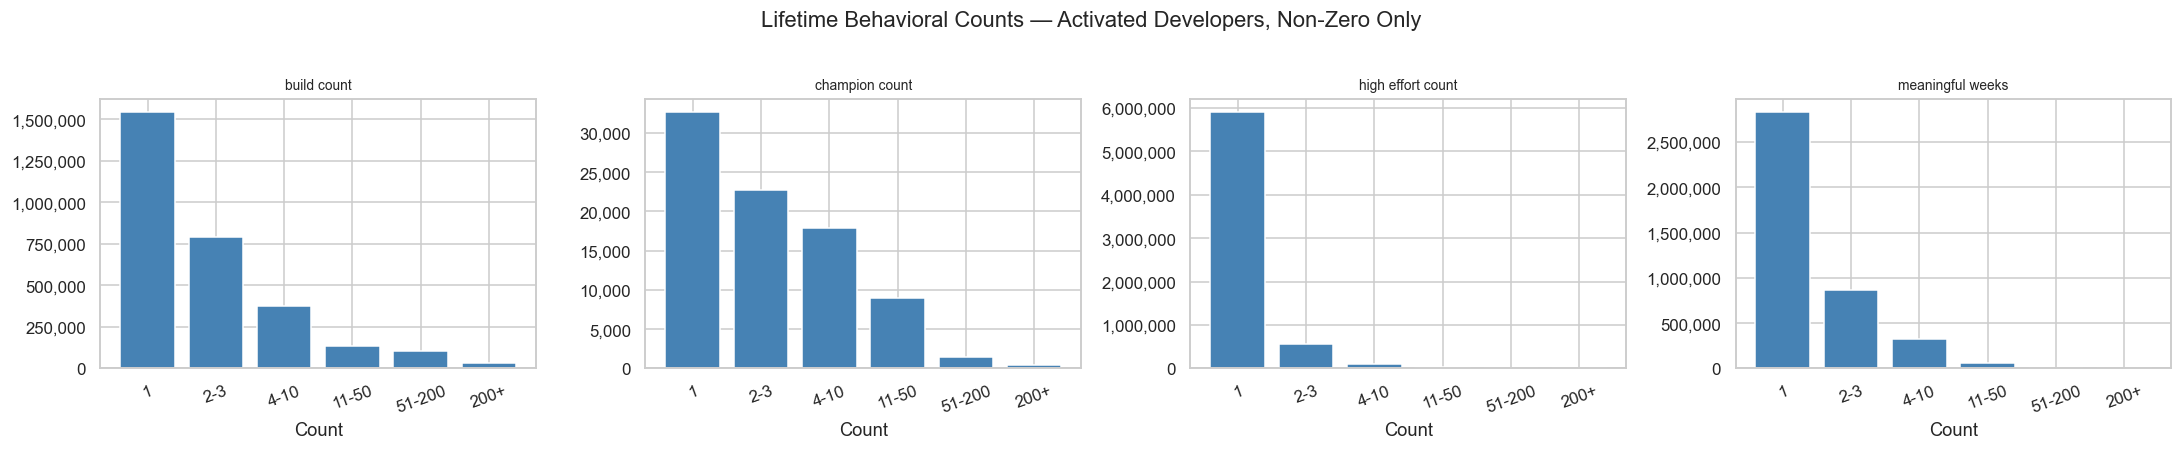

In [13]:
# Bucket histograms for behavioral features — activated, non-zero only
bucket_sql = """
    SELECT
        CASE
            WHEN {col} = 1    THEN '1'
            WHEN {col} <= 3   THEN '2-3'
            WHEN {col} <= 10  THEN '4-10'
            WHEN {col} <= 50  THEN '11-50'
            WHEN {col} <= 200 THEN '51-200'
            ELSE '200+'
        END AS bucket,
        MIN({col}) AS sort_key,
        COUNT(*) AS developers
    FROM {T} WHERE is_activated=1 AND {col} > 0
    GROUP BY 1 ORDER BY sort_key
"""

fig, axes = plt.subplots(1, len(behav_cols), figsize=(5*len(behav_cols), 4))
for ax, col in zip(axes, behav_cols):
    df = con.execute(bucket_sql.format(col=col, T=T)).fetchdf()
    if df.empty:
        ax.set_title(f'{col}\n(no data)')
        continue
    ax.bar(df['bucket'], df['developers'], color='steelblue')
    ax.set_title(col.replace('lifetime_','').replace('_',' '), fontsize=9)
    ax.set_xlabel('Count')
    ax.tick_params(axis='x', rotation=20)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Lifetime Behavioral Counts — Activated Developers, Non-Zero Only', y=1.02)
plt.tight_layout()
plt.show()

## 7. Journey State Analysis
v4 has two journey state columns: `behavior_journey_stage_30d` (new behavior-based) and `current_journey_state_30d` (carried from v3 logic). Both are analyzed below.

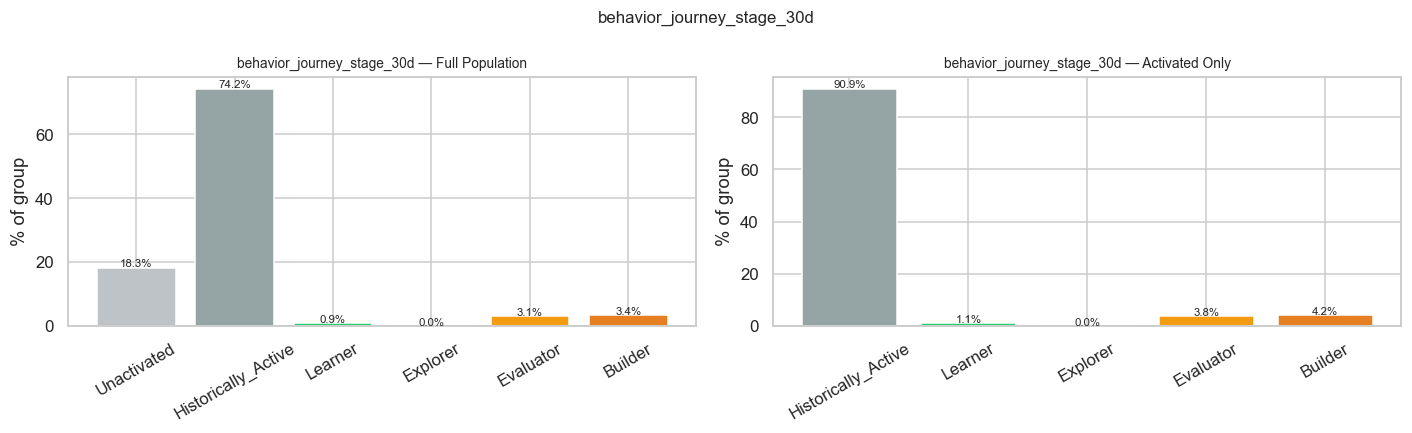

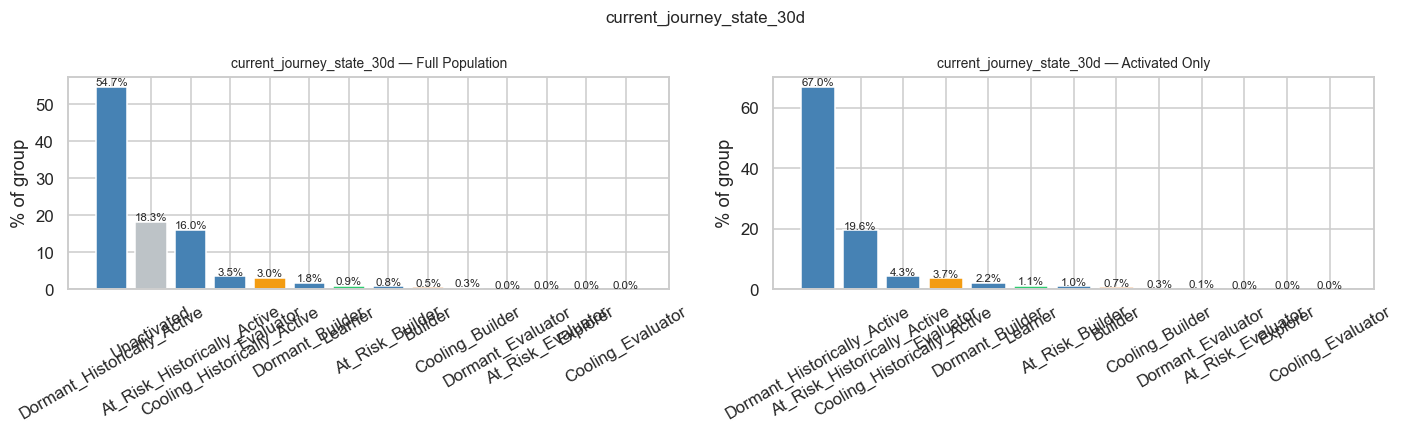

In [14]:
# v4 journey state columns — use whichever exist
behavior_col = 'behavior_journey_stage_30d'
legacy_col   = 'current_journey_state_30d'
journey_cols = [c for c in [behavior_col, legacy_col] if c in all_cols]

# New stage order for behavior_journey_stage_30d
behavior_order = ['Unactivated', 'Historically_Active', 'Learner', 'Explorer',
                  'Evaluator', 'Builder', 'Champion']
legacy_order   = ['Discover', 'Learn', 'Evaluate', 'Build', 'Champion', 'Dormant']

state_colors = {
    'Unactivated': '#bdc3c7', 'Historically_Active': '#95a5a6',
    'Learner': '#2ecc71',     'Explorer': '#27ae60',
    'Evaluator': '#f39c12',   'Builder': '#e67e22',
    'Champion': '#9b59b6',    'Dormant': '#e74c3c',
    'Discover': '#3498db',    'Learn': '#2ecc71',
    'Evaluate': '#f39c12',    'Build': '#e67e22',
}

for col in journey_cols:
    s_order = behavior_order if col == behavior_col else legacy_order
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ax, (pop_filter, pop_label) in zip(axes, [
        ('1=1', 'Full Population'),
        ('is_activated = 1', 'Activated Only'),
    ]):
        vc = con.execute(f"""
            SELECT {col} AS state, COUNT(*) AS developers,
                   ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 1) AS pct
            FROM {T} WHERE {pop_filter}
            GROUP BY 1 ORDER BY 2 DESC
        """).fetchdf()
        vc['sort'] = vc['state'].map({s: i for i, s in enumerate(s_order)}).fillna(99)
        vc = vc.sort_values('sort')
        bars = ax.bar(vc['state'], vc['pct'],
                      color=[state_colors.get(s, 'steelblue') for s in vc['state']])
        ax.set_title(f'{col} — {pop_label}', fontsize=9)
        ax.set_ylabel('% of group')
        ax.tick_params(axis='x', rotation=30)
        for bar, (_, row) in zip(bars, vc.iterrows()):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f"{row['pct']:.1f}%", ha='center', fontsize=7.5)

    plt.suptitle(col, fontsize=11)
    plt.tight_layout()
    plt.show()

,value,developers,pct
0,Tourist,4976445,53.05
1,Unactivated,1721230,18.35
2,Dormant_Build,1015390,10.82
3,Dormant_Learn,360345,3.84
4,Dormant_Evaluate,233676,2.49
5,AtRisk_Build,212335,2.26
6,Active_Build,198074,2.11
7,Active_Discover,141923,1.51
8,AtRisk_Learn,115334,1.23
9,FreeEmail,109622,1.17


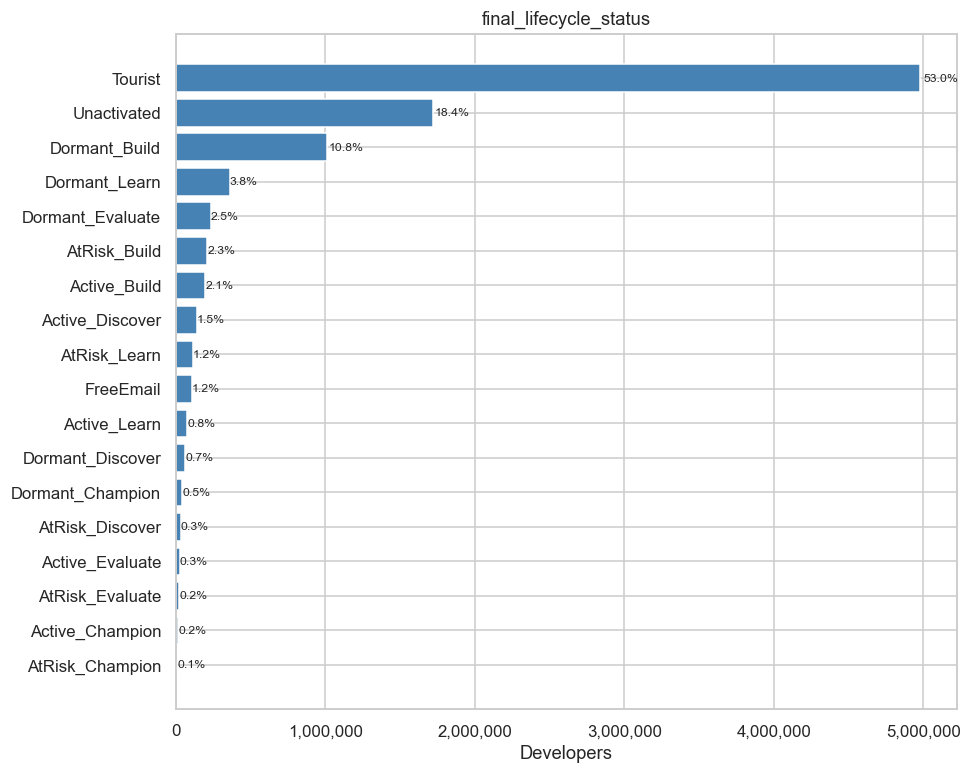

,value,developers,pct
0,Historically_Active,6963992,74.23
1,Unactivated,1721230,18.35
2,Builder,319991,3.41
3,Evaluator,289432,3.09
4,Learner,85487,0.91
5,Explorer,1376,0.01


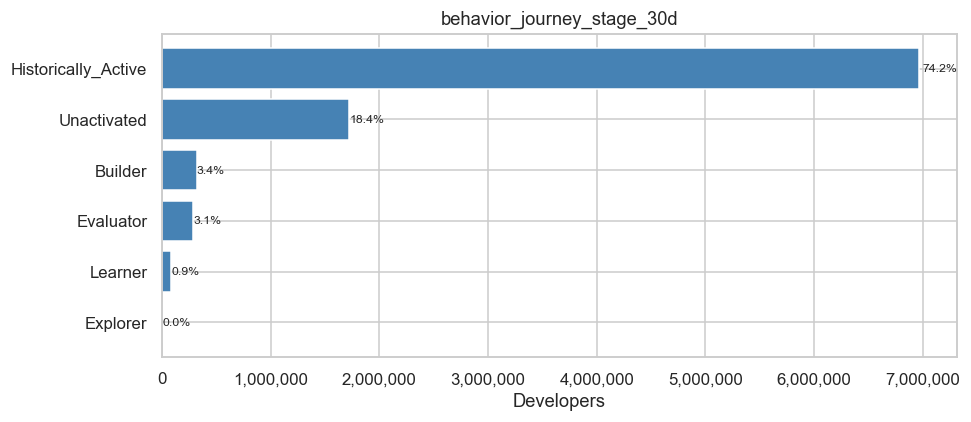

In [15]:
# final_lifecycle_status (new in v4) and behavior_journey_stage_30d breakdown
for cat_col in [c for c in ['final_lifecycle_status', 'behavior_journey_stage_30d'] if c in all_cols]:
    vc = con.execute(f"""
        SELECT {cat_col} AS value, COUNT(*) AS developers,
               ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 2) AS pct
        FROM {T} GROUP BY 1 ORDER BY 2 DESC LIMIT 25
    """).fetchdf()
    display(vc)

    fig, ax = plt.subplots(figsize=(9, max(4, len(vc) * 0.4)))
    ax.barh(vc['value'].astype(str)[::-1], vc['developers'][::-1], color='steelblue')
    ax.set_xlabel('Developers')
    ax.set_title(cat_col)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    for i, (_, row) in enumerate(vc[::-1].iterrows()):
        ax.text(row['developers'] * 1.005, i, f"{row['pct']:.1f}%", va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

## 8. Dormancy Deep Dive (Activated Population)

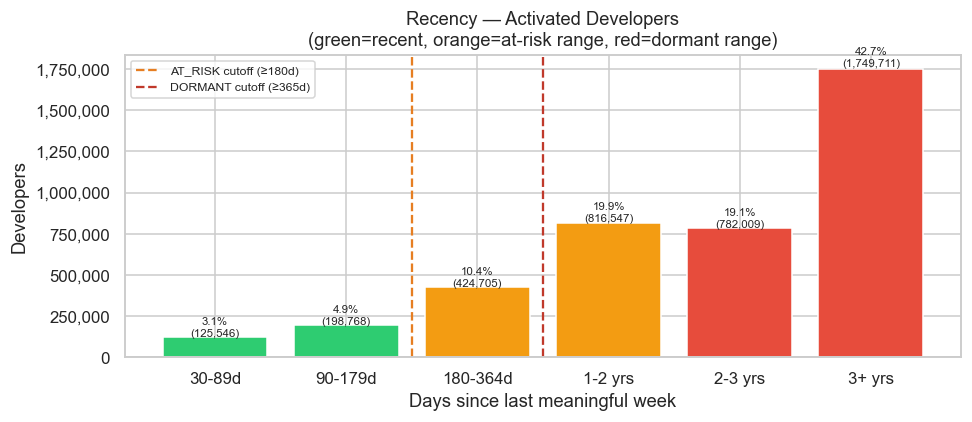

,bucket,developers,pct
0,30-89d,125546,3.10
1,90-179d,198768,4.90
2,180-364d,424705,10.40
3,1-2 yrs,816547,19.90
4,2-3 yrs,782009,19.10
5,3+ yrs,1749711,42.70


In [16]:
# Days since last meaningful week — among activated developers only
days_data = con.execute(f"""
    SELECT
        CASE
            WHEN days_since_last_meaningful_week < 30   THEN '< 30d'
            WHEN days_since_last_meaningful_week < 90   THEN '30-89d'
            WHEN days_since_last_meaningful_week < 180  THEN '90-179d'
            WHEN days_since_last_meaningful_week < 365  THEN '180-364d'
            WHEN days_since_last_meaningful_week < 730  THEN '1-2 yrs'
            WHEN days_since_last_meaningful_week < 1095 THEN '2-3 yrs'
            ELSE '3+ yrs'
        END AS bucket,
        MIN(days_since_last_meaningful_week) AS sort_key,
        COUNT(*) AS developers,
        ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 1) AS pct
    FROM {T}
    WHERE is_activated = 1 AND days_since_last_meaningful_week IS NOT NULL
    GROUP BY 1 ORDER BY sort_key
""").fetchdf()

# Bucket order for x-axis positioning
bucket_order = ['< 30d','30-89d','90-179d','180-364d','1-2 yrs','2-3 yrs','3+ yrs']
days_data['x_pos'] = days_data['bucket'].map({b: i for i, b in enumerate(bucket_order)})

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors_days = ['#2ecc71','#2ecc71','#f39c12','#f39c12','#e74c3c','#e74c3c','#e74c3c']
bars = ax.bar(days_data['bucket'], days_data['developers'], color=bar_colors_days[:len(days_data)])

# Cutoff lines between buckets
# AT_RISK threshold: >=180d → between '90-179d' (idx 2) and '180-364d' (idx 3)
# DORMANT threshold: >=365d → between '180-364d' (idx 3) and '1-2 yrs' (idx 4)
at_risk_x = days_data['bucket'].tolist().index('90-179d') + 0.5  if '90-179d' in days_data['bucket'].values else 2.5
dormant_x  = days_data['bucket'].tolist().index('180-364d') + 0.5 if '180-364d' in days_data['bucket'].values else 3.5

ax.axvline(at_risk_x, color='#e67e22', linestyle='--', linewidth=1.5, label='AT_RISK cutoff (≥180d)')
ax.axvline(dormant_x,  color='#c0392b', linestyle='--', linewidth=1.5, label='DORMANT cutoff (≥365d)')

ax.set_ylabel('Developers')
ax.set_xlabel('Days since last meaningful week')
ax.set_title('Recency — Activated Developers\n(green=recent, orange=at-risk range, red=dormant range)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=8)
for bar, (_, row) in zip(bars, days_data.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f"{row['pct']:.1f}%\n({row['developers']:,})", ha='center', fontsize=7.5)
plt.tight_layout()
plt.show()

display(days_data[['bucket','developers','pct']])

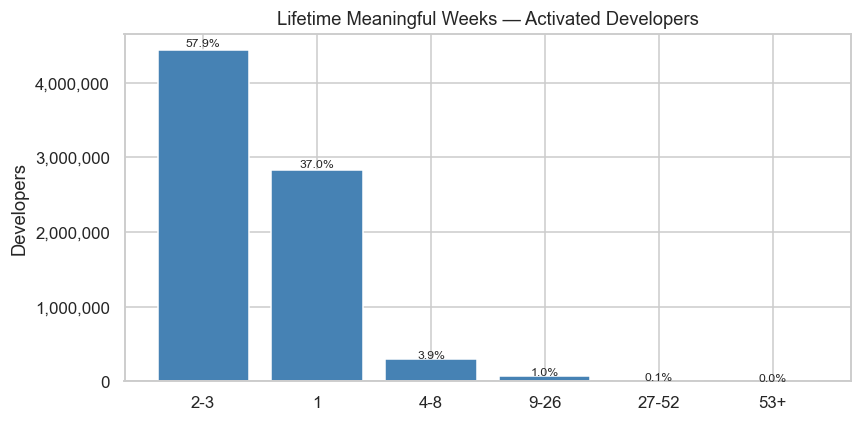

In [17]:
# Meaningful weeks — among activated developers
mw_data = con.execute(f"""
    SELECT
        CASE
            WHEN lifetime_meaningful_weeks = 1  THEN '1'
            WHEN lifetime_meaningful_weeks <= 3  THEN '2-3'
            WHEN lifetime_meaningful_weeks <= 8  THEN '4-8'
            WHEN lifetime_meaningful_weeks <= 26 THEN '9-26'
            WHEN lifetime_meaningful_weeks <= 52 THEN '27-52'
            ELSE '53+'
        END AS bucket,
        MIN(lifetime_meaningful_weeks) AS sort_key,
        COUNT(*) AS developers,
        ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 1) AS pct
    FROM {T} WHERE is_activated = 1
    GROUP BY 1 ORDER BY sort_key
""").fetchdf()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(mw_data['bucket'], mw_data['developers'], color='steelblue')
ax.set_ylabel('Developers')
ax.set_title('Lifetime Meaningful Weeks — Activated Developers')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for i, (_, row) in enumerate(mw_data.iterrows()):
    ax.text(i, row['developers'] * 1.01, f"{row['pct']:.1f}%", ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## 9. Time Window Feature Correlations (Log-Transformed, Activated Developers)

## 9a. New v4 Features — Effort Score, Persona Entropy, Lifecycle Status

,developer_effort_level,developer_effort_rank,developers,pct,avg_score
0,very high effort,4,766035,8.20,1.46
1,high effort,3,1151291,12.30,0.72
2,medium effort,2,2152014,22.90,0.47
3,low effort,1,3590938,38.30,0.29
4,no activity,0,1721230,18.30,0.00


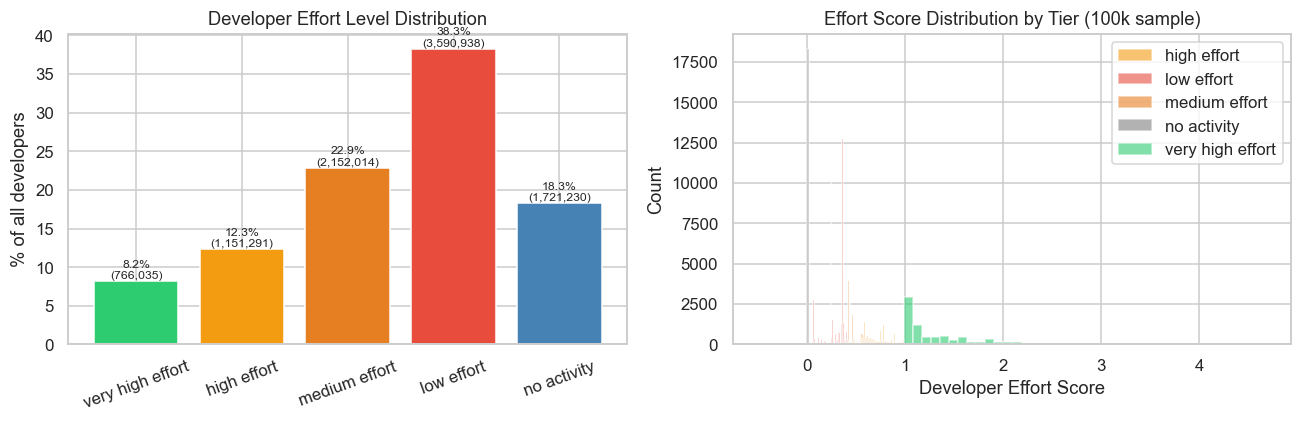


--- Persona Entropy ---


,p25,p50,mean,p75,p90
0,0.00,0.09,0.23,0.43,0.63


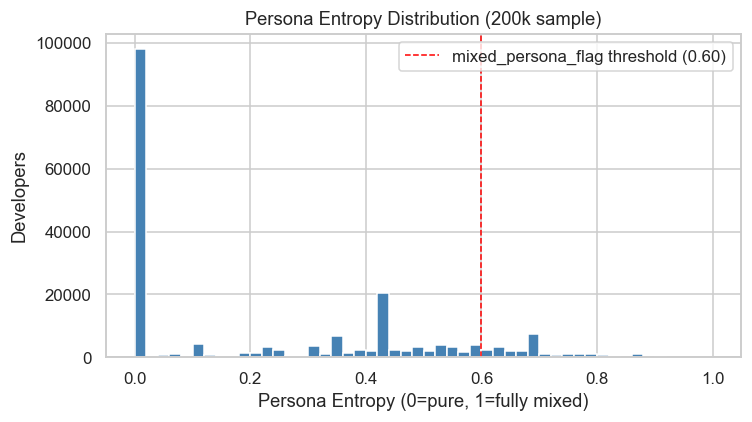

In [18]:
# Developer effort level distribution (new in v4)
if 'developer_effort_level' in all_cols:
    effort = con.execute(f"""
        SELECT developer_effort_level, developer_effort_rank,
               COUNT(*) AS developers,
               ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 1) AS pct,
               ROUND(AVG(developer_effort_score), 3) AS avg_score
        FROM {T}
        WHERE developer_effort_level IS NOT NULL
        GROUP BY 1, 2 ORDER BY 2 DESC
    """).fetchdf()
    display(effort)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    tier_colors = {'very high effort': '#2ecc71', 'high effort': '#f39c12',
                   'medium effort': '#e67e22', 'low effort': '#e74c3c'}
    bar_colors = [tier_colors.get(t, 'steelblue') for t in effort['developer_effort_level']]
    axes[0].bar(effort['developer_effort_level'], effort['pct'], color=bar_colors)
    axes[0].set_title('Developer Effort Level Distribution')
    axes[0].set_ylabel('% of all developers')
    axes[0].tick_params(axis='x', rotation=20)
    for i, (_, row) in enumerate(effort.iterrows()):
        axes[0].text(i, row['pct'] + 0.3, f"{row['pct']:.1f}%\n({row['developers']:,})",
                     ha='center', fontsize=8)

    # Effort score distribution (sample)
    effort_sample = con.execute(f"""
        SELECT developer_effort_score, developer_effort_level
        FROM {T} WHERE developer_effort_score IS NOT NULL
        USING SAMPLE 100000 ROWS
    """).fetchdf()
    for level, grp in effort_sample.groupby('developer_effort_level'):
        axes[1].hist(grp['developer_effort_score'], bins=40, alpha=0.6,
                     label=level, color=tier_colors.get(level, 'gray'))
    axes[1].set_xlabel('Developer Effort Score')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Effort Score Distribution by Tier (100k sample)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Persona entropy distribution
if 'persona_entropy' in all_cols:
    print('\n--- Persona Entropy ---')
    entropy_stats = con.execute(f"""
        SELECT
            APPROX_QUANTILE(persona_entropy, 0.25) AS p25,
            APPROX_QUANTILE(persona_entropy, 0.50) AS p50,
            ROUND(AVG(persona_entropy), 3) AS mean,
            APPROX_QUANTILE(persona_entropy, 0.75) AS p75,
            APPROX_QUANTILE(persona_entropy, 0.90) AS p90
        FROM {T} WHERE persona_entropy IS NOT NULL
    """).fetchdf()
    display(entropy_stats)

    entropy_sample = con.execute(f"""
        SELECT persona_entropy FROM {T}
        WHERE persona_entropy IS NOT NULL
        USING SAMPLE 200000 ROWS
    """).fetchdf()

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(entropy_sample['persona_entropy'], bins=50, color='steelblue', edgecolor='white')
    ax.set_xlabel('Persona Entropy (0=pure, 1=fully mixed)')
    ax.set_ylabel('Developers')
    ax.set_title('Persona Entropy Distribution (200k sample)')
    ax.axvline(0.60, color='red', linestyle='--', linewidth=1, label='mixed_persona_flag threshold (0.60)')
    ax.legend()
    plt.tight_layout()
    plt.show()

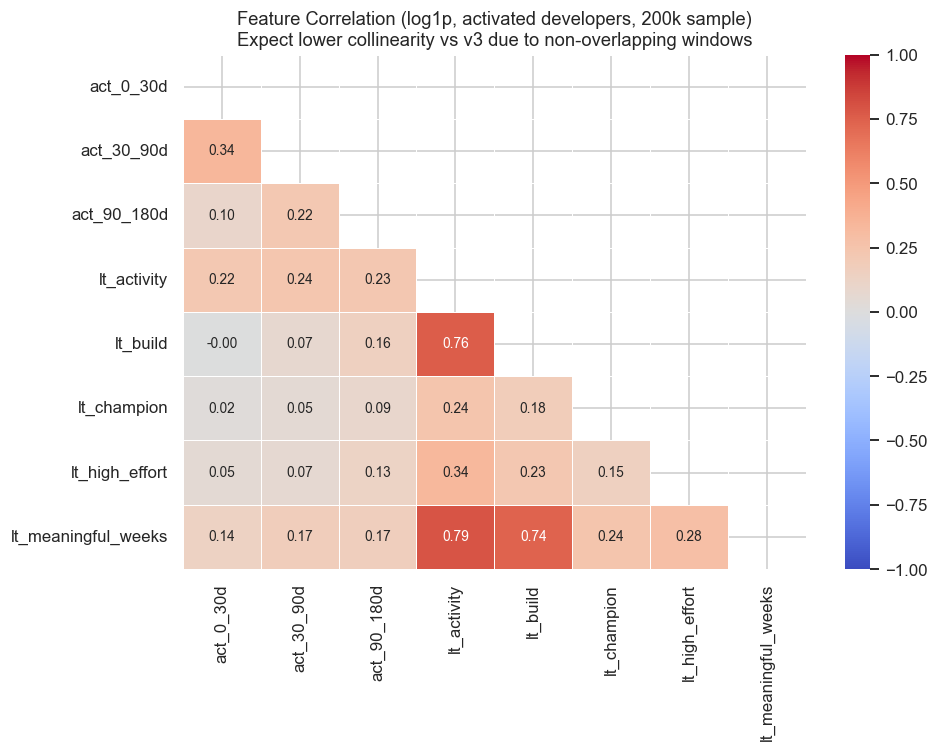

In [19]:
# Non-overlapping windows reduce collinearity vs v3's cumulative windows
# Filter to activated developers; log1p to handle zero-heavy counts
window_cols = [c for c in [
    'activity_count_0_30d', 'activity_count_30_90d', 'activity_count_90_180d',
    'lifetime_activity_count', 'lifetime_build_count',
    'lifetime_champion_count', 'lifetime_high_effort_count',
    'lifetime_meaningful_weeks'
] if c in all_cols]

sample = con.execute(f"""
    SELECT {', '.join(window_cols)}
    FROM {T}
    WHERE is_activated = 1
    USING SAMPLE 200000 ROWS
""").fetchdf()

log_sample = np.log1p(sample.fillna(0))
log_sample.columns = (
    log_sample.columns
    .str.replace('activity_count_', 'act_')
    .str.replace('lifetime_', 'lt_')
    .str.replace('_count', '')
)

corr = log_sample.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Feature Correlation (log1p, activated developers, 200k sample)\nExpect lower collinearity vs v3 due to non-overlapping windows')
plt.tight_layout()
plt.show()

# Print highly correlated pairs
pairs = []
cols = corr.columns.tolist()
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        pairs.append({'feature_a': cols[i], 'feature_b': cols[j], 'corr': round(corr.iloc[i,j], 3)})
high_corr = pd.DataFrame(pairs).query('corr > 0.85').sort_values('corr', ascending=False)
if not high_corr.empty:
    print('Pairs with correlation > 0.85 (flag for modeling team):')
    display(high_corr)

## 10. Cross-Segment Breakdowns by Persona

,persona,total_developers,activation_rate_pct,median_lifetime_activity,median_meaningful_weeks,pct_mixed_persona
0,CUDA,3519981,99.70,3,1.00,30.00
1,Learning_Community,516432,93.70,2,0.00,35.60
2,Robotics,590804,92.60,3,1.00,24.10
3,Simulation,570051,89.80,2,1.00,4.20
4,GenAI,2314671,87.70,2,0.00,38.60
5,Unknown,1869569,30.80,0,0.00,0.00


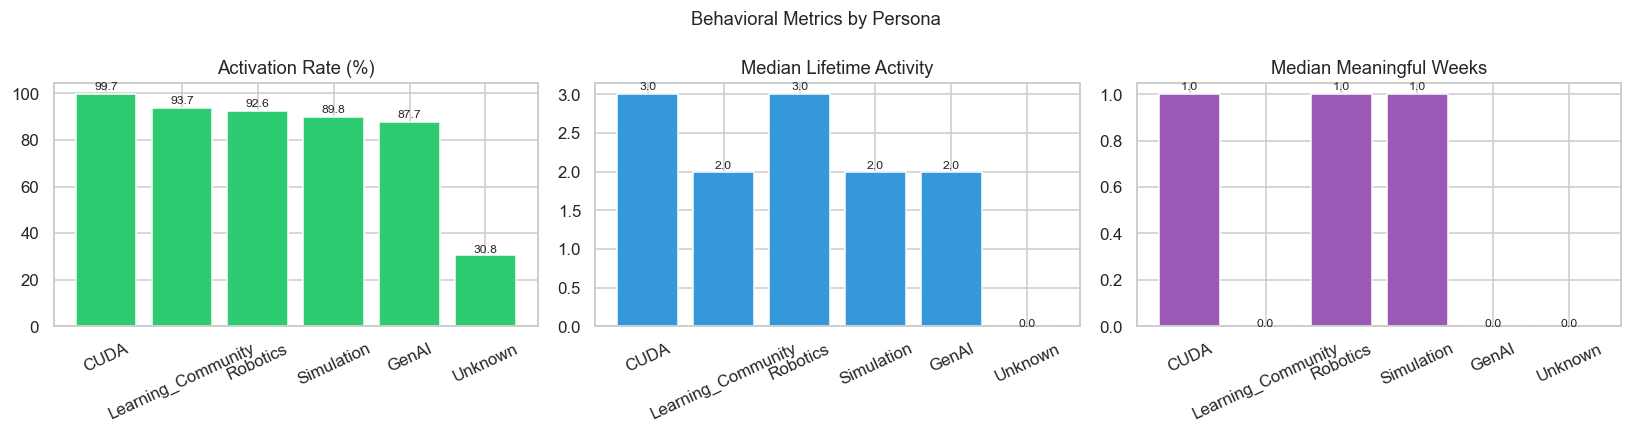

In [20]:
# Activation rate and behavioral medians by persona
persona_summary = con.execute(f"""
    SELECT
        persona,
        COUNT(*) AS total_developers,
        ROUND(AVG(is_activated)*100, 1) AS activation_rate_pct,
        APPROX_QUANTILE(lifetime_activity_count, 0.5) AS median_lifetime_activity,
        APPROX_QUANTILE(lifetime_meaningful_weeks, 0.5) AS median_meaningful_weeks,
        ROUND(AVG(mixed_persona_flag)*100, 1) AS pct_mixed_persona
    FROM {T}
    GROUP BY 1 ORDER BY activation_rate_pct DESC
""").fetchdf()
display(persona_summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [('activation_rate_pct', 'Activation Rate (%)', '#2ecc71'),
           ('median_lifetime_activity', 'Median Lifetime Activity', '#3498db'),
           ('median_meaningful_weeks', 'Median Meaningful Weeks', '#9b59b6')]

for ax, (col, label, color) in zip(axes, metrics):
    ax.bar(persona_summary['persona'], persona_summary[col], color=color)
    ax.set_title(label)
    ax.tick_params(axis='x', rotation=25)
    for i, (_, row) in enumerate(persona_summary.iterrows()):
        ax.text(i, row[col] * 1.02, f"{row[col]:.1f}", ha='center', fontsize=8)

plt.suptitle('Behavioral Metrics by Persona', fontsize=12)
plt.tight_layout()
plt.show()

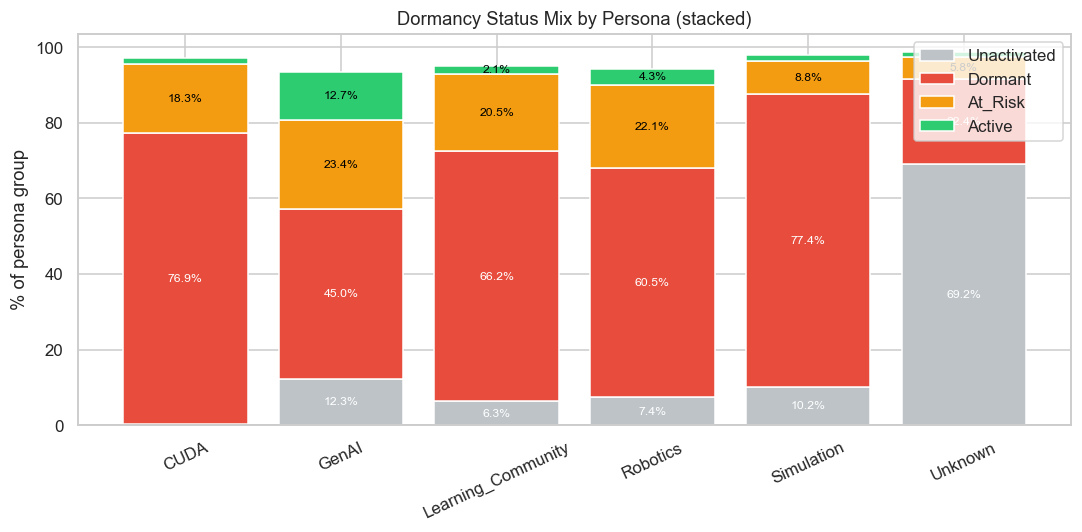

In [21]:
# Dormancy mix by persona
dorm_by_persona = con.execute(f"""
    SELECT persona, dormancy_status, COUNT(*) AS developers,
           ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER (PARTITION BY persona), 1) AS pct
    FROM {T} GROUP BY 1, 2
""").fetchdf()

pivot = dorm_by_persona.pivot(index='persona', columns='dormancy_status', values='pct').fillna(0)
status_order = [c for c in ['Unactivated','Dormant','At_Risk','Active'] if c in pivot.columns]
pivot = pivot[status_order]

fig, ax = plt.subplots(figsize=(10, 5))
status_colors = {'Unactivated':'#bdc3c7','Dormant':'#e74c3c','At_Risk':'#f39c12','Active':'#2ecc71'}
bottom = np.zeros(len(pivot))
for status in status_order:
    vals = pivot[status].values
    ax.bar(pivot.index, vals, bottom=bottom, label=status, color=status_colors.get(status, 'gray'))
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 2:
            ax.text(i, b + v/2, f'{v:.1f}%', ha='center', va='center', fontsize=8, color='white' if status in ['Dormant','Unactivated'] else 'black')
    bottom += vals

ax.set_ylabel('% of persona group')
ax.set_title('Dormancy Status Mix by Persona (stacked)')
ax.tick_params(axis='x', rotation=25)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

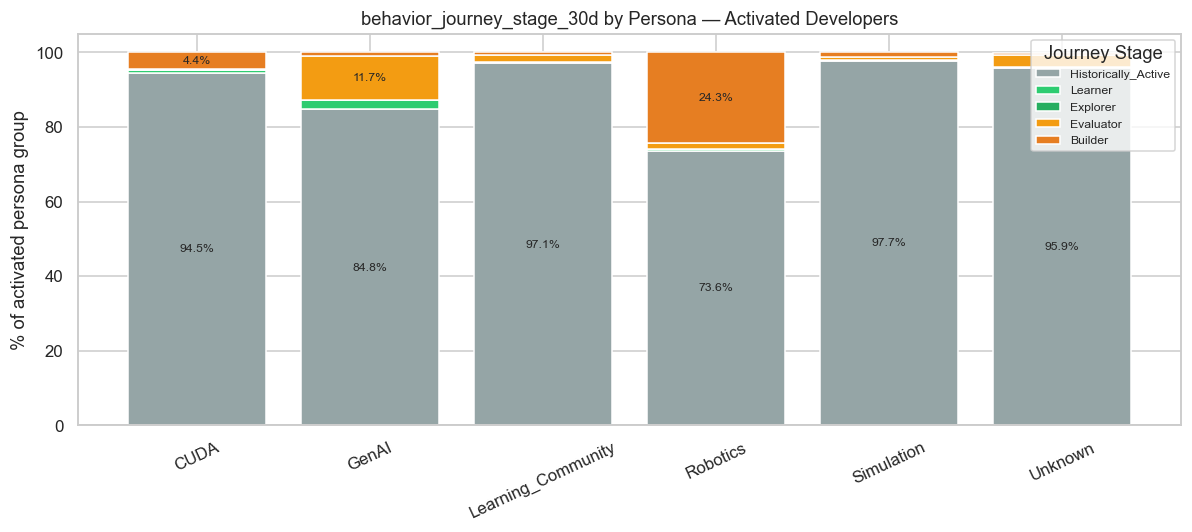

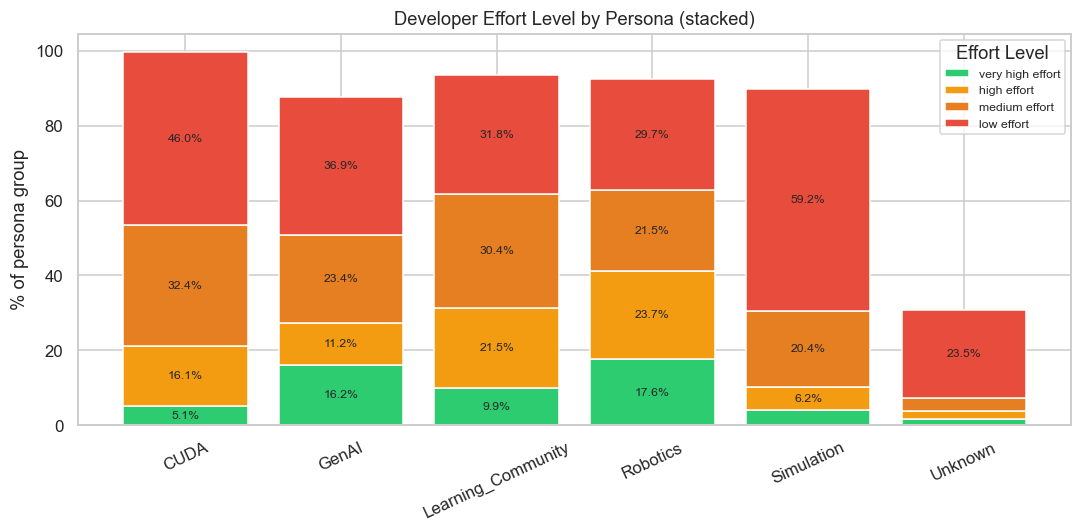

In [22]:
# Journey stage by persona — activated developers only
# Use behavior_journey_stage_30d if available, fall back to current_journey_state_30d
journey_col_for_seg = next(
    (c for c in ['behavior_journey_stage_30d', 'current_journey_state_30d'] if c in all_cols), None
)

if journey_col_for_seg:
    s_order = behavior_order if journey_col_for_seg == 'behavior_journey_stage_30d' else legacy_order

    journey_by_persona = con.execute(f"""
        SELECT persona, {journey_col_for_seg} AS journey_state,
               COUNT(*) AS developers,
               ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER (PARTITION BY persona), 1) AS pct
        FROM {T}
        WHERE is_activated = 1
        GROUP BY 1, 2
    """).fetchdf()

    pivot_j = journey_by_persona.pivot(index='persona', columns='journey_state', values='pct').fillna(0)
    j_order = [c for c in s_order if c in pivot_j.columns]
    pivot_j = pivot_j[j_order]

    fig, ax = plt.subplots(figsize=(11, 5))
    bottom = np.zeros(len(pivot_j))
    for state in j_order:
        vals = pivot_j[state].values
        ax.bar(pivot_j.index, vals, bottom=bottom, label=state,
               color=state_colors.get(state, 'steelblue'))
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 3:
                ax.text(i, b + v/2, f'{v:.1f}%', ha='center', va='center', fontsize=8)
        bottom += vals

    ax.set_ylabel('% of activated persona group')
    ax.set_title(f'{journey_col_for_seg} by Persona — Activated Developers')
    ax.tick_params(axis='x', rotation=25)
    ax.legend(loc='upper right', title='Journey Stage', fontsize=8)
    plt.tight_layout()
    plt.show()

# Effort level by persona
if 'developer_effort_level' in all_cols:
    effort_by_persona = con.execute(f"""
        SELECT persona, developer_effort_level,
               COUNT(*) AS developers,
               ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER (PARTITION BY persona), 1) AS pct
        FROM {T}
        WHERE developer_effort_level IS NOT NULL
        GROUP BY 1, 2
    """).fetchdf()

    pivot_e = effort_by_persona.pivot(index='persona', columns='developer_effort_level', values='pct').fillna(0)
    e_order = [c for c in ['very high effort','high effort','medium effort','low effort'] if c in pivot_e.columns]
    pivot_e = pivot_e[e_order]

    fig, ax = plt.subplots(figsize=(10, 5))
    bottom = np.zeros(len(pivot_e))
    e_colors = {'very high effort':'#2ecc71','high effort':'#f39c12','medium effort':'#e67e22','low effort':'#e74c3c'}
    for level in e_order:
        vals = pivot_e[level].values
        ax.bar(pivot_e.index, vals, bottom=bottom, label=level, color=e_colors.get(level,'gray'))
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 5:
                ax.text(i, b + v/2, f'{v:.1f}%', ha='center', va='center', fontsize=8)
        bottom += vals

    ax.set_ylabel('% of persona group')
    ax.set_title('Developer Effort Level by Persona (stacked)')
    ax.tick_params(axis='x', rotation=25)
    ax.legend(loc='upper right', title='Effort Level', fontsize=8)
    plt.tight_layout()
    plt.show()

## 11. Unique Activity Breadth (Activated Developers)

Active developers (dormancy_status='Active'): 418,049  (4.5% of all)


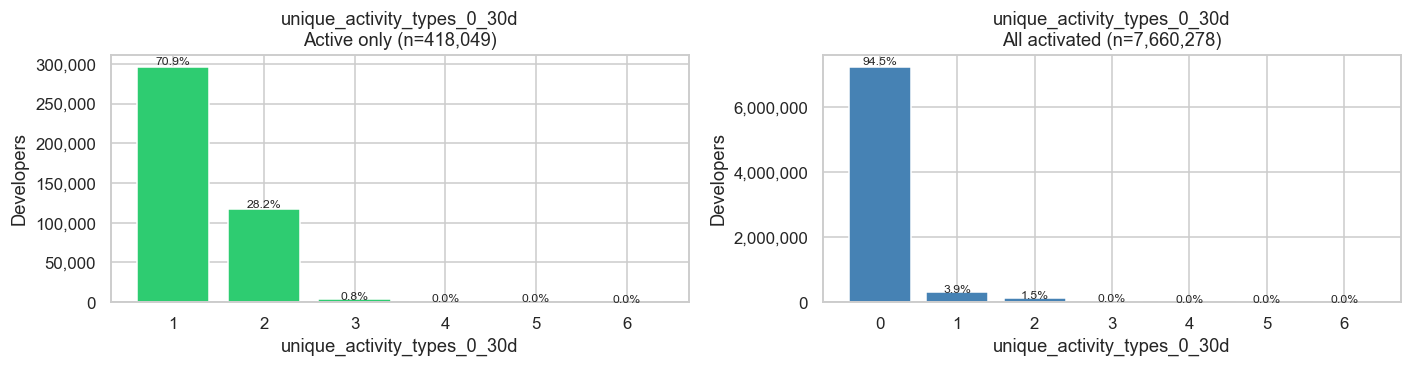

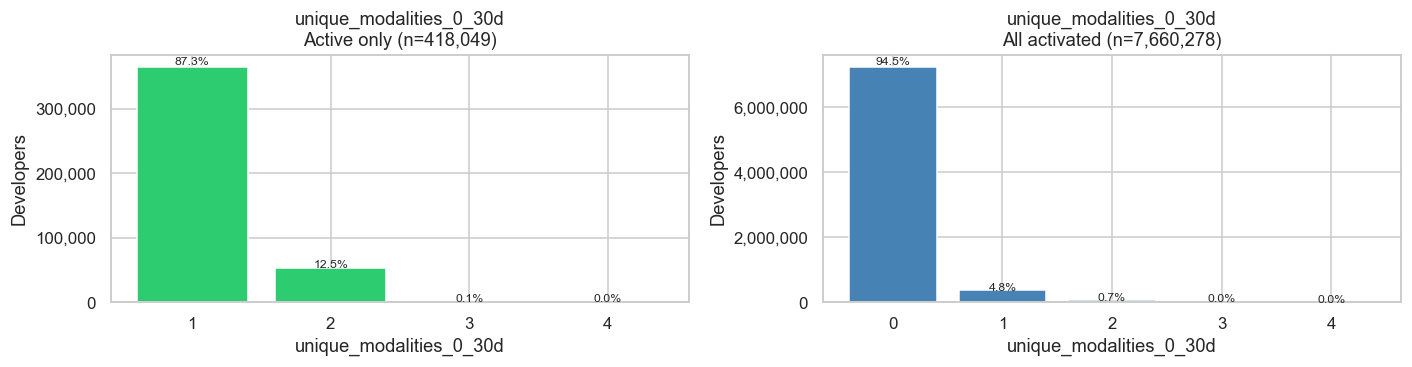

In [23]:
# unique_activity_types and unique_modalities — Active developers only
# (activated-but-dormant devs have 0 recent activity by definition, so showing
#  all activated is misleading; filter to dormancy_status = 'Active')
breadth_cols = [c for c in [
    'unique_activity_types_0_30d', 'unique_modalities_0_30d',
    'unique_activity_types_30d',   'unique_modalities_30d'   # fallback for older schema
] if c in all_cols][:2]  # take first two found

n_active_only = con.execute(f"SELECT COUNT(*) FROM {T} WHERE dormancy_status = 'Active'").fetchone()[0]
print(f"Active developers (dormancy_status='Active'): {n_active_only:,}  ({n_active_only/total*100:.1f}% of all)")

for col in breadth_cols:
    vc_active = con.execute(f"""
        SELECT {col} AS value, COUNT(*) AS developers,
               ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 1) AS pct
        FROM {T} WHERE dormancy_status = 'Active'
        GROUP BY 1 ORDER BY 1
    """).fetchdf()

    vc_all_act = con.execute(f"""
        SELECT {col} AS value, COUNT(*) AS developers,
               ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(), 1) AS pct
        FROM {T} WHERE is_activated = 1
        GROUP BY 1 ORDER BY 1
    """).fetchdf()

    fig, axes = plt.subplots(1, 2, figsize=(13, 3.5), sharey=False)
    for ax, df, label, color in zip(
        axes,
        [vc_active, vc_all_act],
        [f'Active only (n={n_active_only:,})', f'All activated (n={n_activated:,})'],
        ['#2ecc71', 'steelblue']
    ):
        ax.bar(df['value'].astype(str), df['developers'], color=color)
        ax.set_xlabel(col)
        ax.set_ylabel('Developers')
        ax.set_title(f'{col}\n{label}')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
        for i, (_, row) in enumerate(df.iterrows()):
            ax.text(i, row['developers'] * 1.01, f"{row['pct']:.1f}%", ha='center', fontsize=8)

    plt.tight_layout()
    plt.show()

## 12. Key Findings Summary

In [24]:
print('=' * 60)
print('KEY FINDINGS')
print('=' * 60)
print(f'\nTotal developers:     {total:>10,}')
print(f'Activated (21.9%):    {n_activated:>10,}')
print(f'Unactivated (78.1%):  {n_unactivated:>10,}')

print('\n--- Dormancy (full population) ---')
for _, row in dormancy.iterrows():
    print(f"  {row['dormancy_status']:<15} {row['developers']:>10,}  ({row['pct']:.1f}%)")

print('\n--- Activity coverage ---')
for _, row in any_df.iterrows():
    print(f"  {row['window']:<12}: {row['pct_any_activity']:.1f}% of all developers have any activity")

print('\n--- Persona mix (full population) ---')
for _, row in persona_dist.iterrows():
    print(f"  {row['persona']:<20} {row['developers']:>10,}  ({row['pct_all']:.1f}%)")

con.close()
print('\nConnection closed.')

KEY FINDINGS

Total developers:      9,381,508
Activated (21.9%):     7,660,278
Unactivated (78.1%):   1,721,230

--- Dormancy (full population) ---
  Dormant          5,304,852  (56.5%)
  Unactivated      1,721,230  (18.4%)
  At_Risk          1,580,877  (16.9%)
  Active             418,049  (4.5%)
  Cooling            356,500  (3.8%)

--- Activity coverage ---
  0 30d       : 4.5% of all developers have any activity
  30 90d      : 4.5% of all developers have any activity
  90 180d     : 5.6% of all developers have any activity
  lifetime activity count: 81.7% of all developers have any activity

--- Persona mix (full population) ---
  CUDA                  3,519,981  (37.5%)
  GenAI                 2,314,671  (24.7%)
  Unknown               1,869,569  (19.9%)
  Robotics                590,804  (6.3%)
  Simulation              570,051  (6.1%)
  Learning_Community      516,432  (5.5%)

Connection closed.
